# Predicting Customer Churn with Nori

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Synthefy/synthefy-nori/blob/main/examples/notebooks/nori-churn-prediction.ipynb)

Build one row per subscriber from real account, usage, and service records; use Nori to produce a continuous churn score; and compare it with a 500-configuration XGBoost search. A separate retention threshold converts the score into an outreach decision.

This is the runnable companion to [Better Churn Prediction with Nori](https://synthefy.com/blog/nori-churn-prediction). It uses the public Cell2Cell telecom churn dataset. The records were donated by an anonymous U.S. wireless carrier through the Teradata Center for Customer Relationship Management at Duke University. The carrier name is anonymized, but the customer fields remain readable.

## Setup

Run the next cell in a fresh Google Colab runtime. It installs Nori and the remaining dependencies. The following cell downloads and extracts Cell2Cell automatically; no repository clone or local data files are required.

Dataset: [Cell2Cell telecom churn](https://www.kaggle.com/datasets/jpacse/datasets-for-churn-telecom)

In [1]:
# Install only when the runtime does not already have Nori.
try:
    import synthefy_nori  # noqa: F401
except ImportError:
    %pip install -q "synthefy-nori[eval]" xgboost joblib ipywidgets

In [2]:
import os
import sys
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from synthefy_nori import NoriRegressor
from xgboost import XGBClassifier

TEST_SEED = 42
XGB_SEARCH_CONFIGS = int(os.environ.get("XGB_SEARCH_CONFIGS", "500"))
XGB_JOBS = int(os.environ.get("XGB_JOBS", str(min(8, os.cpu_count() or 1))))
DATA_URL = "https://www.kaggle.com/api/v1/datasets/download/jpacse/datasets-for-churn-telecom"

default_data_dir = "/content/cell2cell" if "google.colab" in sys.modules else "/tmp/nori-cell2cell"
data_dir = Path(os.environ.get("CELL2CELL_DATA_DIR", default_data_dir))
data_dir.mkdir(parents=True, exist_ok=True)
data_path = data_dir / "cell2celltrain.csv"

if not data_path.exists():
    archive_path = data_dir / "cell2cell.zip"
    print("Downloading the public Cell2Cell dataset...")
    urllib.request.urlretrieve(DATA_URL, archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extract("cell2celltrain.csv", data_dir)

raw = pd.read_csv(data_path)
print(f"Loaded {len(raw):,} labeled Cell2Cell subscriber records.")
display(raw.head())

Loaded 51,047 labeled Cell2Cell subscriber records.


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## Build one row per customer

Cell2Cell already provides one snapshot per subscriber. We organize the readable fields into three blocks:

1. **Account context** — tenure, revenue, equipment, subscription, credit, and household attributes.
2. **Usage patterns** — monthly minutes, recent change, overage, roaming, and call mix.
3. **Service experience** — dropped or blocked calls, customer-care contacts, and retention activity.

The feature function keeps those source fields and adds a small set of ratios that make customers easier to compare. A production table can add payment events, support-resolution time, product adoption, satisfaction, and other signals known at the scoring date.

In [3]:
def build_customer_features(frame: pd.DataFrame) -> pd.DataFrame:
    features = frame.drop(columns=["CustomerID"]).copy()
    active_subs = pd.to_numeric(features["ActiveSubs"], errors="coerce").clip(lower=1)
    months = pd.to_numeric(features["MonthsInService"], errors="coerce").clip(lower=1)
    minutes = pd.to_numeric(features["MonthlyMinutes"], errors="coerce").clip(lower=1)
    total_calls = (
        pd.to_numeric(features["OutboundCalls"], errors="coerce").fillna(0)
        + pd.to_numeric(features["InboundCalls"], errors="coerce").fillna(0)
        + pd.to_numeric(features["ReceivedCalls"], errors="coerce").fillna(0)
    ).clip(lower=1)

    # Account context.
    features["active_subscriber_share"] = active_subs / pd.to_numeric(
        features["UniqueSubs"], errors="coerce"
    ).clip(lower=1)
    features["revenue_per_active_subscriber"] = pd.to_numeric(
        features["MonthlyRevenue"], errors="coerce"
    ) / active_subs
    features["equipment_age_share_of_tenure"] = pd.to_numeric(
        features["CurrentEquipmentDays"], errors="coerce"
    ) / (30.4 * months)

    # Usage patterns.
    features["minutes_per_active_subscriber"] = minutes / active_subs
    features["overage_share_of_minutes"] = pd.to_numeric(
        features["OverageMinutes"], errors="coerce"
    ) / minutes
    features["roaming_calls_per_1000_minutes"] = 1000 * pd.to_numeric(
        features["RoamingCalls"], errors="coerce"
    ) / minutes

    # Service experience.
    features["dropped_or_blocked_call_rate"] = pd.to_numeric(
        features["DroppedBlockedCalls"], errors="coerce"
    ) / total_calls
    features["care_calls_per_1000_minutes"] = 1000 * pd.to_numeric(
        features["CustomerCareCalls"], errors="coerce"
    ) / minutes
    features["accepted_retention_offer_rate"] = pd.to_numeric(
        features["RetentionOffersAccepted"], errors="coerce"
    ) / pd.to_numeric(features["RetentionCalls"], errors="coerce").clip(lower=1)
    return features.replace([np.inf, -np.inf], np.nan)


y = raw["Churn"].eq("Yes").to_numpy(dtype=float)
X = build_customer_features(raw.drop(columns=["Churn"]))

# A fixed 5,000-row sample keeps the complete notebook practical on CPU.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    train_size=4000,
    test_size=1000,
    random_state=TEST_SEED,
    stratify=y,
)

categorical_columns = X_train_raw.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
numeric_columns = X_train_raw.columns.difference(categorical_columns).tolist()

# Every learned preprocessing value comes from the 4,000 context customers.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="infrequent_if_exist",
                        max_categories=20,
                        sparse_output=False,
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ],
)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

print(f"{len(X_train):,} labeled context customers")
print(f"{len(X_test):,} held-out test customers")
print(f"{X_train.shape[1]} numeric model inputs after encoding")
print(f"{y.mean():.1%} churn rate in the full labeled file")

4,000 labeled context customers
1,000 held-out test customers
132 numeric model inputs after encoding
28.8% churn rate in the full labeled file


## Nori produces a score; the threshold produces the retention decision

The context labels are zero and one, but Nori returns a continuous value. We clip small excursions outside the label range before presenting it as a 0–1 churn score. The score ranks customers by similarity to the churn examples in context; it is not automatically a calibrated probability.

The 0.50 threshold below is illustrative. In production, select a threshold from out-of-fold predictions on the training customers to match campaign capacity, intervention cost, or a required precision or recall level. Do not choose it on the held-out test set.

In [4]:
nori = NoriRegressor(
    model="nori-30m",
    device="cpu",
    # Reported benchmarks must preserve every context row.
    memory_policy="exact",
)
nori.fit(X_train, y_train)
nori_raw_score = np.asarray(nori.predict(X_test, output_type="mean")).reshape(-1)
nori_score = np.clip(nori_raw_score, 0.0, 1.0)

RETENTION_THRESHOLD = 0.5
nori_prediction = (nori_score >= RETENTION_THRESHOLD).astype(int)
nori_metrics = {
    "PR-AUC": float(average_precision_score(y_test, nori_raw_score)),
    "ROC-AUC": float(roc_auc_score(y_test, nori_raw_score)),
}

preview_columns = [
    "MonthsInService",
    "MonthlyRevenue",
    "CurrentEquipmentDays",
    "MonthlyMinutes",
    "PercChangeMinutes",
    "OverageMinutes",
    "DroppedBlockedCalls",
    "CustomerCareCalls",
]
decision_preview = X_test_raw[preview_columns].copy()
decision_preview["churn_score"] = nori_score
decision_preview["prioritize_for_outreach"] = nori_prediction

display(decision_preview.head().style.format({
    "MonthlyRevenue": "${:.2f}",
    "churn_score": "{:.3f}",
}))
display(pd.Series(nori_metrics, name="Nori-30M"))

Mixed precision is not supported for CPU inference, so it has been automatically disabled


,MonthsInService,MonthlyRevenue,CurrentEquipmentDays,MonthlyMinutes,PercChangeMinutes,OverageMinutes,DroppedBlockedCalls,CustomerCareCalls,churn_score,prioritize_for_outreach
47634,10,$95.85,186.000000,1490.000000,-158.000000,34.000000,20.700000,6.300000,0.170,0
10168,22,$66.14,292.000000,776.000000,-234.000000,104.000000,14.300000,2.700000,0.406,0
31901,14,$101.88,408.000000,1055.000000,287.000000,59.000000,15.300000,1.300000,0.241,0
40519,13,$37.70,376.000000,399.000000,21.000000,0.000000,0.700000,2.000000,0.322,0
45640,7,$134.04,213.000000,1948.000000,-688.000000,210.000000,9.700000,1.300000,0.283,0


PR-AUC     0.397519
ROC-AUC    0.631515
Name: Nori-30M, dtype: float64

## Compare with tuned XGBoost

XGBoost receives the identical encoded table. Its configuration is selected with five-fold stratified cross-validation using only the 4,000 context customers. The default is the full 500-configuration search used in the blog; set `XGB_SEARCH_CONFIGS` before running this notebook to shorten the search while experimenting.

In [5]:
def xgboost_parameter_grid(y_train: np.ndarray) -> dict[str, list[float | int]]:
    imbalance = float(np.sum(y_train == 0) / np.sum(y_train == 1))
    return {
        "n_estimators": [100, 200, 350, 500, 750, 1000],
        "max_depth": [2, 3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.02, 0.04, 0.06, 0.10, 0.15, 0.20],
        "subsample": [0.55, 0.70, 0.85, 1.0],
        "colsample_bytree": [0.55, 0.70, 0.85, 1.0],
        "min_child_weight": [1, 2, 4, 8, 12, 20],
        "gamma": [0.0, 0.02, 0.05, 0.10, 0.25, 0.50, 1.0],
        "reg_alpha": [0.0, 0.001, 0.01, 0.05, 0.10, 0.50, 1.0],
        "reg_lambda": [0.10, 0.50, 1.0, 2.0, 5.0, 10.0, 20.0],
        "scale_pos_weight": [1.0, np.sqrt(imbalance), imbalance],
    }


def make_xgboost(params: dict[str, object]) -> XGBClassifier:
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=1,
        random_state=TEST_SEED,
        verbosity=0,
        **params,
    )


def score_xgboost_candidate(params, X, y, splits):
    fold_scores = []
    for train_index, validation_index in splits:
        model = make_xgboost(params)
        model.fit(X[train_index], y[train_index])
        score = model.predict_proba(X[validation_index])[:, 1]
        fold_scores.append(average_precision_score(y[validation_index], score))
    return float(np.mean(fold_scores)), params


candidates = list(ParameterSampler(
    xgboost_parameter_grid(y_train),
    n_iter=XGB_SEARCH_CONFIGS,
    random_state=TEST_SEED,
))
splits = list(StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=TEST_SEED,
).split(X_train, y_train))

search_results = Parallel(n_jobs=XGB_JOBS, prefer="threads", verbose=5)(
    delayed(score_xgboost_candidate)(params, X_train, y_train, splits)
    for params in candidates
)
search_results.sort(key=lambda result: result[0], reverse=True)
best_cv_pr_auc, best_params = search_results[0]

xgboost = make_xgboost(best_params)
xgboost.fit(X_train, y_train)
xgboost_score = xgboost.predict_proba(X_test)[:, 1]
xgboost_metrics = {
    "PR-AUC": float(average_precision_score(y_test, xgboost_score)),
    "ROC-AUC": float(roc_auc_score(y_test, xgboost_score)),
}

print(f"Searched {len(search_results)} XGBoost configurations")
print(f"Best cross-validated PR-AUC: {best_cv_pr_auc:.4f}")
display(pd.DataFrame({
    "Nori-30M": nori_metrics,
    "XGBoost (tuned)": xgboost_metrics,
}).T)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.5s


[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   17.5s


[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   48.7s


[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:  1.4min


[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:  2.1min


Searched 500 XGBoost configurations
Best cross-validated PR-AUC: 0.4191


[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:  2.5min finished


,PR-AUC,ROC-AUC
Nori-30M,0.397519,0.631515
XGBoost (tuned),0.395970,0.636953


## Result

PR-AUC is the primary metric because churn is the smaller class and the business needs a useful ranking for retention outreach. ROC-AUC is included as a second threshold-independent view. Nori leads the 500-configuration XGBoost search on PR-AUC, while XGBoost is slightly higher on ROC-AUC.

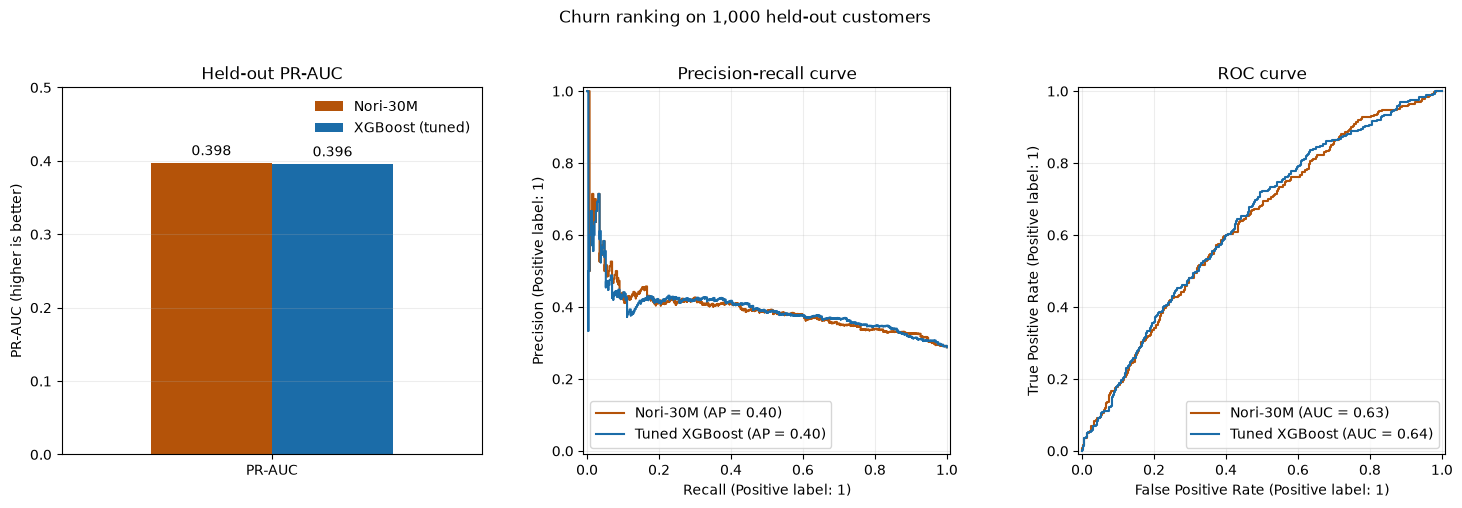

,PR-AUC,ROC-AUC
Nori-30M,0.397519,0.631515
XGBoost (tuned),0.395970,0.636953


In [6]:
comparison = pd.DataFrame({
    "Nori-30M": nori_metrics,
    "XGBoost (tuned)": xgboost_metrics,
}).T

primary = comparison[["PR-AUC"]]
figure, axes = plt.subplots(1, 3, figsize=(15, 4.8))
primary.T.plot(
    kind="bar",
    color=["#B45309", "#1B6CA8"],
    width=0.68,
    ax=axes[0],
)
axes[0].set_ylim(0, 0.5)
axes[0].set_ylabel("PR-AUC (higher is better)")
axes[0].set_title("Held-out PR-AUC")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.22)
axes[0].legend(frameon=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

PrecisionRecallDisplay.from_predictions(
    y_test,
    nori_raw_score,
    name="Nori-30M",
    curve_kwargs={"color": "#B45309"},
    ax=axes[1],
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    xgboost_score,
    name="Tuned XGBoost",
    curve_kwargs={"color": "#1B6CA8"},
    ax=axes[1],
)
axes[1].set_title("Precision-recall curve")
axes[1].grid(alpha=0.22)

RocCurveDisplay.from_predictions(
    y_test,
    nori_raw_score,
    name="Nori-30M",
    curve_kwargs={"color": "#B45309"},
    ax=axes[2],
)
RocCurveDisplay.from_predictions(
    y_test,
    xgboost_score,
    name="Tuned XGBoost",
    curve_kwargs={"color": "#1B6CA8"},
    ax=axes[2],
)
axes[2].set_title("ROC curve")
axes[2].grid(alpha=0.22)

figure.suptitle("Churn ranking on 1,000 held-out customers", y=1.02)
plt.tight_layout()
plt.show()

comparison

## Add external context around each customer

The benchmark predicts individual subscriber churn. A production row can add competitor plans and promotions by region, local service availability or outages, public quarterly carrier results, and regional economic indicators. Join values using the date they were published, not the period they describe.

```python
# Keep only public information that was available by the scoring date.
customer_rows = pd.merge_asof(
    customer_rows.sort_values("score_date"),
    market_signals.sort_values("published_at"),
    left_on="score_date",
    right_on="published_at",
    by=["region", "carrier"],
    direction="backward",
)
```

To test whether external data helps, keep the time-based validation split fixed and compare customer features alone with the same rows plus external features. Cell2Cell has neither scoring dates nor carrier identity, so these signals are not part of the published benchmark.

## Extend to family and business accounts

For a family plan, team, or business customer, build one row for the whole group at a scoring date. Useful features include onboarding completion, active-member share, usage per member or seat, feature adoption, admin and champion engagement, renewal timing, payment events, and support escalations.

```python
group_rows["onboarding_rate"] = (
    group_rows["onboarded_members"] / group_rows["invited_members"].clip(lower=1)
)
group_rows["member_activation_rate"] = (
    group_rows["active_members"] / group_rows["eligible_members"].clip(lower=1)
)
group_rows["feature_adoption_rate"] = (
    group_rows["adopted_key_features"] / group_rows["eligible_key_features"].clip(lower=1)
)
```

Resources:

- [Better Churn Prediction with Nori](https://synthefy.com/blog/nori-churn-prediction)
- [Cell2Cell telecom churn dataset](https://www.kaggle.com/datasets/jpacse/datasets-for-churn-telecom)
- [FCC Broadband Data Collection](https://help.bdc.fcc.gov/hc/en-us/articles/7682769466395-Broadband-Data-Collection-BDC-FAQs)
- [SEC EDGAR APIs](https://www.sec.gov/search-filings/edgar-application-programming-interfaces)
- [BLS Public Data API](https://www.bls.gov/audience/developers.htm)
- [Nori quickstart](https://docs.synthefy.com/nori/quickstart)
- [Synthefy Nori on GitHub](https://github.com/Synthefy/synthefy-nori)